In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter
from scipy.fftpack import dct, idct
from scipy.ndimage import binary_fill_holes, convolve
from scipy.signal import convolve2d
from skimage.transform import resize
from skimage.measure import label, regionprops
from skimage.filters import difference_of_gaussians
from skimage.restoration import denoise_bilateral
from skimage.metrics import structural_similarity
from PIL import Image, ImageEnhance, ImageOps
import math
import random
import json
import yaml

import os

from src.preprocessing import scale_range, histogram_equalization, run_pipeline, pipeline

In [2]:
# EDIT DIRECTORY VARIABLES AS NEEDED

# --- Input directory variables
source_train_root = "data/raw_data/CheXpert-v1.0 batch 4 (train 3)/"
source_valid_root = "data/raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid/"
source_test_root = "data/raw_data/test/"

# --- train/valid/test csv
train_filepath = "data/processed_data/train_df.csv"
valid_filepath = "data/processed_data/valid_df.csv"
test_filepath = "data/processed_data/test_df.csv"

# --- Image sizes
img_dims = [224, 384, 512]
img_dim = 224

In [3]:
# ---Preprocessing variables
# Value range for scaling image array
scale_min = 0
scale_max = 255


In [4]:
# --- Load the training/validation csvs
train_df = pd.read_csv(train_filepath)
valid_df = pd.read_csv(valid_filepath)
test_df = pd.read_csv(test_filepath)

print(f"# rows in train_df: {len(train_df)}")
print(f"# rows in valid_df: {len(valid_df)}")
print(f"# rows in test_df: {len(test_df)}")

# rows in train_df: 121316
# rows in valid_df: 30340
# rows in test_df: 39371


In [5]:
analysis_var = "source_file_path"

In [6]:
train_df.columns

Index(['Cardiomegaly', 'Consolidation', 'Edema', 'Atelectasis',
       'Pleural Effusion', 'floating_file_path', 'source_file_path',
       'base224_file_path', 'base224_file_path2', 'base384_file_path',
       'base384_file_path2', 'base512_file_path', 'base512_file_path2'],
      dtype='object')

Example File Transformations
Image Type = source_file_path --> data/raw_data/CheXpert-v1.0 batch 2 (train 1)/patient19965/study6/view1_frontal.jpg
Image Type = base224_file_path --> data/processed_data/train_valid/patient19965/study6/view1_frontal_224.jpg
Image Type = base384_file_path --> data/processed_data/train_valid/patient19965/study6/view1_frontal_384.jpg
Image Type = base512_file_path --> data/processed_data/train_valid/patient19965/study6/view1_frontal_512.jpg
Image Type = base224_file_path2 --> data/processed_data/train_valid/patient19965/study6/view1_frontal_224_usm.jpg
Image Type = base384_file_path2 --> data/processed_data/train_valid/patient19965/study6/view1_frontal_384_usm.jpg
Image Type = base512_file_path2 --> data/processed_data/train_valid/patient19965/study6/view1_frontal_512_usm.jpg


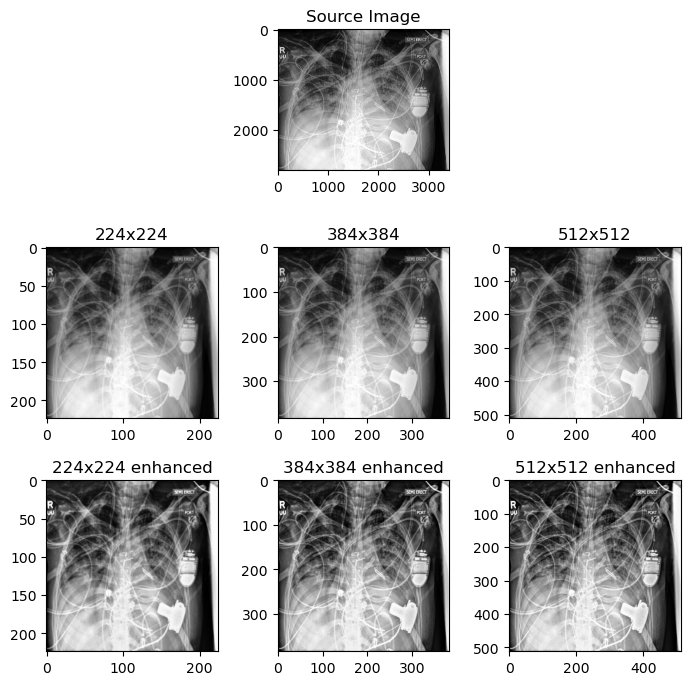

In [16]:
# --- View each iteration of the image
cols = ["source_file_path",
        "base224_file_path", "base384_file_path", "base512_file_path"
        "base224_file_path2", "base384_file_path2", "base512_file_path2"]
plot_cols = [None, "source_file_path", None,
            "base224_file_path", "base384_file_path", "base512_file_path",
            "base224_file_path2", "base384_file_path2", "base512_file_path2"]
titles = [None, "Source Image", None,
            "224x224", "384x384", "512x512",
            "224x224 enhanced", "384x384 enhanced", "512x512 enhanced"]

print("Example File Transformations")
fig,axes = plt.subplots(3,3, figsize=(7,7))
for i,(ax,col_name,title) in enumerate(zip(axes.flatten(), plot_cols, titles)):
    if col_name:
        if col_name in train_df.columns:
            path = train_df.loc[430, col_name]
            print(f"Image Type = {col_name} --> {path}")
            with Image.open(path) as img:
                ax.imshow(img, cmap="gray")
                ax.set(title=title)
    else: ax.axis("off")

plt.tight_layout()
fig.savefig("results/EDA/Visualizing_all_images.jpg")

In [25]:
train_stats = train_df.sample(1000).copy()

In [28]:
%%time
# Compile image information on the training data frame
#
img_heights0, img_widths0 = [], []
max_value0, min_value0, value_range0 = [], [], []
img_mean0, img_var0 = [], []
#
img_heights1, img_widths1 = [], []
max_value1, min_value1, value_range1 = [], [], []
img_mean1, img_var1 = [], []
#
img_heights2, img_widths2 = [], []
max_value2, min_value2, value_range2 = [], [], []
img_mean2, img_var2 = [], []
#
img_heights3, img_widths3 = [], []
max_value3, min_value3, value_range3 = [], [], []
img_mean3, img_var3 = [], []
# --- Record any file paths that caused error for review
error_file_paths = []
#
for i,(source_img_path,base224_file_path,base384_file_path,base512_file_path) in enumerate(zip(train_stats["source_file_path"], 
                                                                                               train_stats[f"base224_file_path"],
                                                                                               train_stats[f"base384_file_path"],
                                                                                               train_stats[f"base512_file_path"]), start=1):
    with Image.open(source_img_path) as img:
        img_arr = np.array(img)
        if scale_min == scale_max:
            error_file_paths.append(source_img_path)
        else:
            img_arr = scale_range(img_arr, scale_min, scale_max)
            (img_height, img_width) = img.size
            img_heights0.append(img_height)
            img_widths0.append(img_width)
            img_max, img_min = img_arr.max(), img_arr.min()
            max_value0.append(img_max)
            min_value0.append(img_min)
            value_range0 = img_max - img_min
            img_mean0.append(img_arr.mean())
            img_var0.append(img_arr.var())
    with Image.open(base224_file_path) as img:
        img_arr = np.array(img)
        if scale_min == scale_max:
            error_file_paths.append(source_img_path)
        else:
            img_arr = scale_range(img_arr, scale_min, scale_max)
            (img_height, img_width) = img.size
            img_heights1.append(img_height)
            img_widths1.append(img_width)
            img_max, img_min = img_arr.max(), img_arr.min()
            max_value1.append(img_max)
            min_value1.append(img_min)
            value_range1 = img_max - img_min
            img_mean1.append(img_arr.mean())
            img_var1.append(img_arr.var())
    with Image.open(base384_file_path) as img:
        img_arr = np.array(img)
        if scale_min == scale_max:
            error_file_paths.append(source_img_path)
        else:
            img_arr = scale_range(img_arr, scale_min, scale_max)
            (img_height, img_width) = img.size
            img_heights2.append(img_height)
            img_widths2.append(img_width)
            img_max, img_min = img_arr.max(), img_arr.min()
            max_value2.append(img_max)
            min_value2.append(img_min)
            value_range2 = img_max - img_min
            img_mean2.append(img_arr.mean())
            img_var2.append(img_arr.var())
    with Image.open(base512_file_path) as img:
        img_arr = np.array(img)
        if scale_min == scale_max:
            error_file_paths.append(source_img_path)
        else:
            img_arr = scale_range(img_arr, scale_min, scale_max)
            (img_height, img_width) = img.size
            img_heights3.append(img_height)
            img_widths3.append(img_width)
            img_max, img_min = img_arr.max(), img_arr.min()
            max_value3.append(img_max)
            min_value3.append(img_min)
            value_range3 = img_max - img_min
            img_mean3.append(img_arr.mean())
            img_var3.append(img_arr.var())
            
train_stats["source_img_height"] = img_heights0
train_stats["source_img_width"] = img_widths0
train_stats["source_img_max"] = max_value0
train_stats["source_img_min"] = min_value0
train_stats["source_img_range"] = value_range0
train_stats["source_img_mean"] = img_mean0
train_stats["source_img_var"] = img_var0
#
train_stats["base224_img_height"] = img_heights1
train_stats["base224_img_width"] = img_widths1
train_stats["base224_img_max"] = max_value1
train_stats["base224_img_min"] = min_value1
train_stats["base224_img_range"] = value_range1
train_stats["base224_img_mean"] = img_mean1
train_stats["base224_img_var"] = img_var1
#
train_stats["base384_img_height"] = img_heights2
train_stats["base384_img_width"] = img_widths2
train_stats["base384_img_max"] = max_value2
train_stats["base384_img_min"] = min_value2
train_stats["base384_img_range"] = value_range2
train_stats["base384_img_mean"] = img_mean2
train_stats["base384_img_var"] = img_var2
#
train_stats["base512_img_height"] = img_heights3
train_stats["base512_img_width"] = img_widths3
train_stats["base512_img_max"] = max_value3
train_stats["base512_img_min"] = min_value3
train_stats["base512_img_range"] = value_range3
train_stats["base512_img_mean"] = img_mean3
train_stats["base512_img_var"] = img_var3

CPU times: total: 1min 55s
Wall time: 3min 14s


In [29]:
#  # --- Viewing the distribution of dimensions
# """
# Analyzing all images in the datasets is quite memory-intensive and takes a long time. Instead, we analyze
# a sample of 1000 images from each
# """
# heights, widths = {}, {}
# dims = {}

# dfs = [train_df, valid_df, test_df]
# df_types = ["train", "valid", "test"]

# for df,df_type in zip(dfs, df_types):
#     img_heights, img_widths, img_dims = [], [], []
#     for i,file_path in enumerate(df[analysis_var].sample(1000)):
#         with Image.open(file_path) as img:
#             (img_height, img_width) = img.size
#             img_heights.append(img_height)
#             img_widths.append(img_width)
#     img_dims.append((img_heights, img_widths))
#     heights[df_type] = img_heights
#     widths[df_type] = img_widths
#     dims[df_type] = img_dims

train
Min width: 1001
Max width: 3480
Min height: 1716
Max height: 4240

valid
Min width: 991
Max width: 3480
Min height: 1693
Max height: 4240

test
Min width: 1741
Max width: 3480
Min height: 1797
Max height: 4240



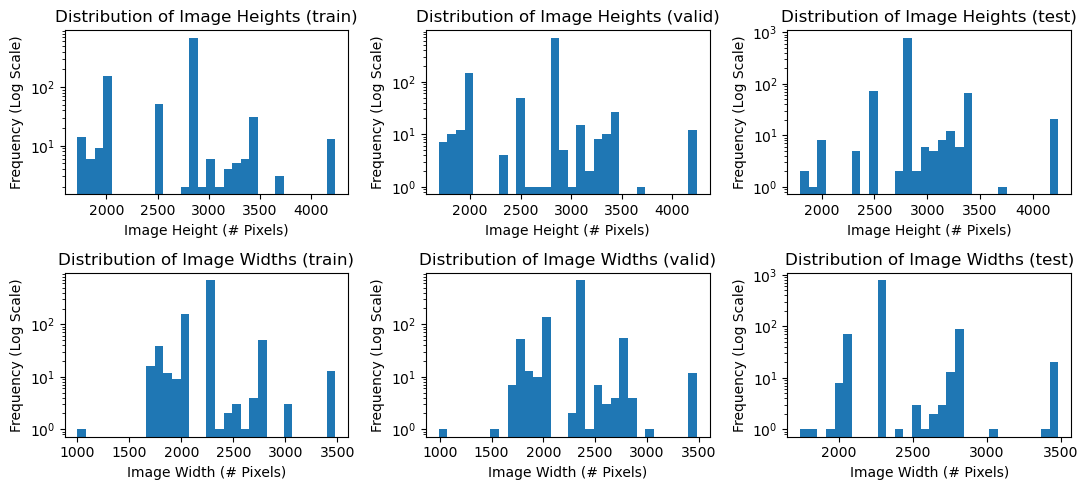

In [31]:
df_type = "test"
bins = 30
fig,ax = plt.subplots(2,3, figsize=(11,5))

for i,df_type in enumerate(df_types):
    img_heights = heights[df_type]
    img_widths = widths[df_type]
    
    min_width, max_width = min(img_widths), max(img_widths)
    min_height, max_height = min(img_heights), max(img_heights)

    print(df_type)
    print(f"Min width: {min_width}")
    print(f"Max width: {max_width}")
    print(f"Min height: {min_height}")
    print(f"Max height: {max_height}")
    print()
    
    ax[(0,i)].hist(img_heights, bins=bins, log=True)
    ax[(0,i)].set(title=f"Distribution of Image Heights ({df_type})", xlabel="Image Height (# Pixels)", ylabel="Frequency (Log Scale)")
    #
    ax[(1,i)].hist(img_widths, bins=bins, log=True)
    ax[(1,i)].set(title=f"Distribution of Image Widths ({df_type})", xlabel="Image Width (# Pixels)", ylabel="Frequency (Log Scale)")
    #

plt.tight_layout()

fig.savefig("results/EDA/img_size_histograms")

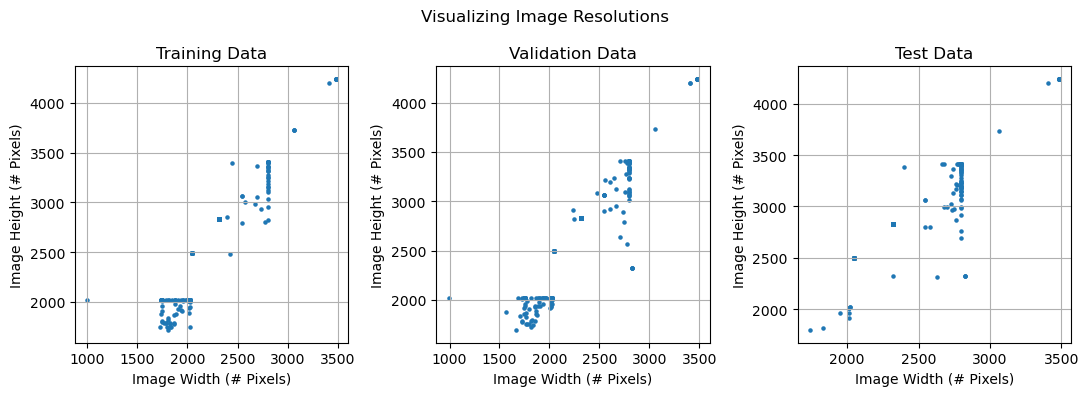

In [32]:
fig,ax = plt.subplots(1,3, figsize=(11,4))

for i,df_type in enumerate(df_types):
    df = dims[df_type]
    img_heights, img_widths = [], []
    for img_dim in dims[df_type]:
        img_heights.append(img_dim[0])
        img_widths.append(img_dim[1])

    ax[i].scatter(img_widths, img_heights, s=5)
    ax[i].set(xlabel="Image Width (# Pixels)", ylabel="Image Height (# Pixels)")
    ax[i].grid()

ax[0].set_title("Training Data")
ax[1].set_title("Validation Data")
ax[2].set_title("Test Data")
plt.suptitle("Visualizing Image Resolutions")
plt.tight_layout()

fig.savefig("results/EDA/img_size_plots")

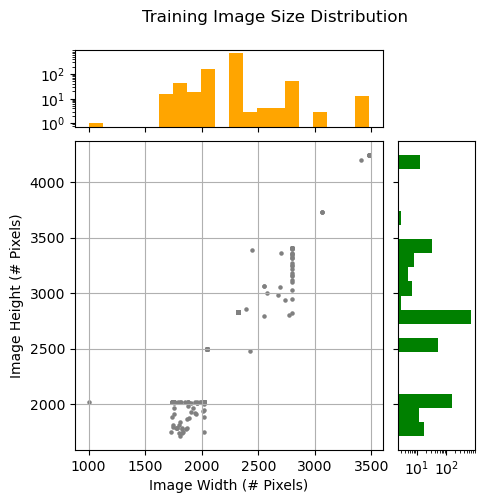

In [33]:
# Plot combined scatter plot and histogram
df_type = "train"
bins = 20

# --- Create grid
fig = plt.figure(figsize=(5,5))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.075, hspace=0.075)
plt.suptitle("Training Image Size Distribution")

# --- Create axes
ax = fig.add_subplot(gs[1,0])
ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histy = fig.add_subplot(gs[1,1], sharey=ax)

# --- Extract data
img_heights, img_widths = [], []
for img_dim in dims[df_type]:
    img_heights.append(img_dim[0])
    img_widths.append(img_dim[1])

# --- Add scatterplot
ax.scatter(img_widths, img_heights, s=5, color="gray")
ax.set(xlabel="Image Width (# Pixels)", ylabel="Image Height (# Pixels)")
ax.grid()

# --- Add histograms
ax_histx.hist(img_widths, bins=bins, color="orange", log=True)
ax_histy.hist(img_heights, bins=bins, orientation="horizontal", color="green", log=True)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

plt.show()
fig.savefig("results/EDA/img_train_scatterhist.png", bbox_inches="tight")

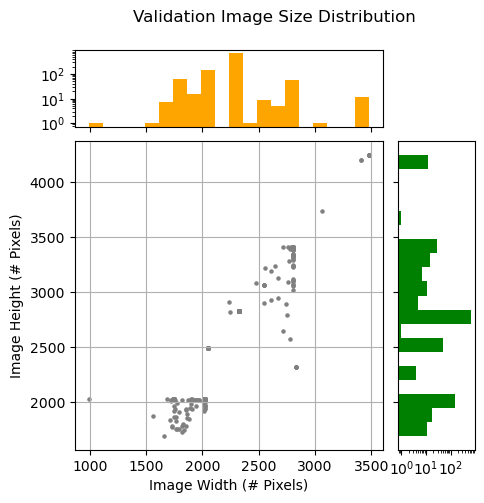

In [34]:
# Plot combined scatter plot and histogram
df_type = "valid"
bins = 20

# --- Create grid
fig = plt.figure(figsize=(5,5))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.075, hspace=0.075)
plt.suptitle("Validation Image Size Distribution")

# --- Create axes
ax = fig.add_subplot(gs[1,0])
ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histy = fig.add_subplot(gs[1,1], sharey=ax)

# --- Extract data
img_heights, img_widths = [], []
for img_dim in dims[df_type]:
    img_heights.append(img_dim[0])
    img_widths.append(img_dim[1])

# --- Add scatterplot
ax.scatter(img_widths, img_heights, s=5, color="gray")
ax.set(xlabel="Image Width (# Pixels)", ylabel="Image Height (# Pixels)")
ax.grid()

# --- Add histograms
ax_histx.hist(img_widths, bins=bins, color="orange", log=True)
ax_histy.hist(img_heights, bins=bins, orientation="horizontal", color="green", log=True)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

plt.show()
fig.savefig("results/EDA/img_valid_scatterhist", bbox_inches="tight")

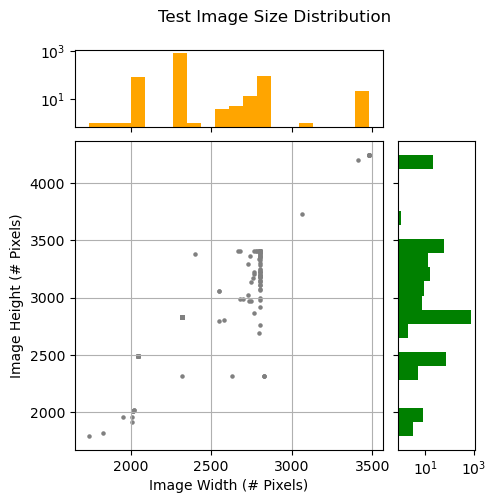

In [35]:
# Plot combined scatter plot and histogram
df_type = "test"
bins = 20

# --- Create grid
fig = plt.figure(figsize=(5,5))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.075, hspace=0.075)
plt.suptitle("Test Image Size Distribution")

# --- Create axes
ax = fig.add_subplot(gs[1,0])
ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histy = fig.add_subplot(gs[1,1], sharey=ax)

# --- Extract data
img_heights, img_widths = [], []
for img_dim in dims[df_type]:
    img_heights.append(img_dim[0])
    img_widths.append(img_dim[1])

# --- Add scatterplot
ax.scatter(img_widths, img_heights, s=5, color="gray")
ax.set(xlabel="Image Width (# Pixels)", ylabel="Image Height (# Pixels)")
ax.grid()

# --- Add histograms
ax_histx.hist(img_widths, bins=bins, color="orange", log=True)
ax_histy.hist(img_heights, bins=bins, orientation="horizontal", color="green", log=True)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

plt.show()
fig.savefig("results/EDA/img_test_scatterhist", bbox_inches="tight")

In [36]:
cols = ["source_file_path", "base224_file_path", "base384_file_path", 
        "source_img_height","source_img_width","source_img_max",
        "source_img_min","source_img_range","source_img_mean",
        "source_img_var",
        "base224_img_height","base224_img_width","base224_img_max",
        "base224_img_min","base224_img_range","base224_img_mean",
        "base224_img_var",
        "base384_img_height","base384_img_width","base384_img_max",
        "base384_img_min","base384_img_range","base384_img_mean",
        "base384_img_var",
        "base512_img_height","base512_img_width","base512_img_max",
        "base512_img_min","base512_img_range","base512_img_mean",
        "base512_img_var"
       ]

In [37]:
train_stats.to_csv(f"data/processed_data/train_stats.csv", index=False)

train_stats = pd.read_csv(f"data/processed_data/train_stats.csv")

In [45]:
# Default image enhancement variables
with open(f"config/pipeline_kwargs.yaml", "r") as params:
    pipeline_kwargs = yaml.safe_load(params) 

In [59]:
# View the average training x-ray
dim0 = 224

avg_img_arr = np.zeros((dim0, dim0))
avg_img_arr_sqrd = np.zeros((dim0, dim0))

### Online mean computations
for i,img_path in enumerate(train_df["source_file_path"].sample(100), start=1):
    img, _ = pipeline(img_path, [dim0], **pipeline_kwargs)
    img_arr = np.array(img[0][:,:])
    img_arr = scale_range(img_arr, scale_min, scale_max)
    avg_img_arr = (1 - (1 / i)) * avg_img_arr + (1 / i) * img_arr
    avg_img_arr_sqrd = (1 - (1/i)) * avg_img_arr_sqrd + (1/i)*(img_arr**2)

var_img_arr = avg_img_arr_sqrd - (avg_img_arr)**2
std_img_arr = np.sqrt(var_img_arr)

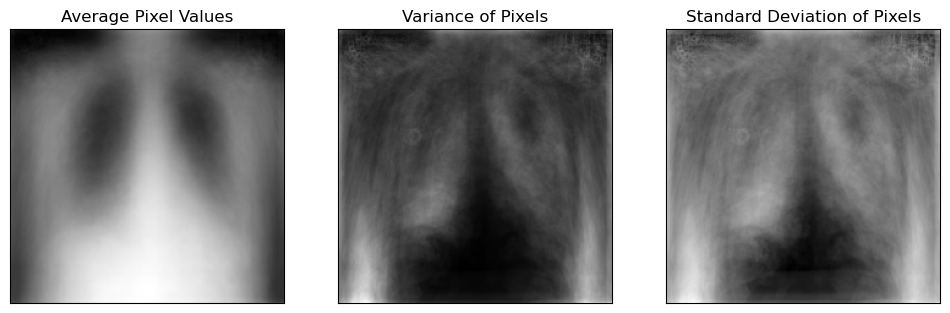

In [60]:
### Show avg/var/std
fig, ax = plt.subplots(1,3, figsize=(12,5))
fig.suptitle=(" ")

ax[0].imshow(avg_img_arr, cmap="gray")
ax[1].imshow(var_img_arr, cmap="gray")
ax[2].imshow(std_img_arr, cmap="gray")

ax[0].set(title="Average Pixel Values", xticks=[], yticks=[])
ax[1].set(title="Variance of Pixels", xticks=[], yticks=[])
ax[2].set(title="Standard Deviation of Pixels", xticks=[], yticks=[])

# plt.tight_layout()
fig.savefig("results/EDA/avg_var_std_pixels.png", bbox_inches="tight")

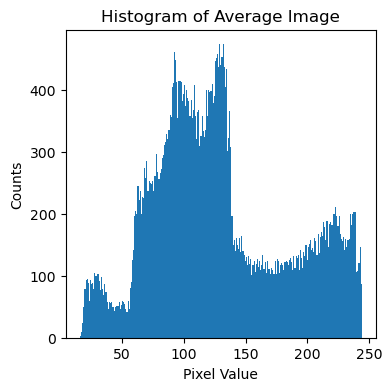

In [61]:
### View the histogram of the average image
fig,ax = plt.subplots(1,1,figsize=(4,4))

###
ax.hist(avg_img_arr.flatten(), bins=255)
ax.set(title="Histogram of Average Image", xlabel="Pixel Value", ylabel="Counts")
fig.savefig("results/EDA/avg_img_histogram.png")

In [62]:
train_stats[cols].describe()

,source_img_height,source_img_width,source_img_max,source_img_min,source_img_range,source_img_mean,source_img_var,base224_img_height,base224_img_width,base224_img_max,...,base384_img_range,base384_img_mean,base384_img_var,base512_img_height,base512_img_width,base512_img_max,base512_img_min,base512_img_range,base512_img_mean,base512_img_var
count,1000.000000,1000.000000,1000.0,1000.0,1000.0,1000.000000,1000.000000,1000.0,1000.0,1000.0,...,1000.0,1000.000000,1000.000000,1000.0,1000.0,1000.0,1000.0,1000.0,1000.000000,1000.000000
mean,2710.255000,2278.089000,255.0,0.0,255.0,129.272409,5472.998882,224.0,224.0,255.0,...,255.0,129.233192,5376.814012,512.0,512.0,255.0,0.0,255.0,129.253534,5392.154536
std,413.952578,268.831969,0.0,0.0,0.0,1.384770,112.459182,0.0,0.0,0.0,...,0.0,1.370554,113.508977,0.0,0.0,0.0,0.0,0.0,1.377586,112.500549
min,1654.000000,1541.000000,255.0,0.0,255.0,111.771195,4968.148400,224.0,224.0,255.0,...,255.0,111.774197,4658.103394,512.0,512.0,255.0,0.0,255.0,111.773525,4768.599732
25%,2828.000000,2320.000000,255.0,0.0,255.0,128.981197,5433.065738,224.0,224.0,255.0,...,255.0,128.952950,5337.672632,512.0,512.0,255.0,0.0,255.0,128.967779,5353.504076
50%,2828.000000,2320.000000,255.0,0.0,255.0,129.268614,5462.617775,224.0,224.0,255.0,...,255.0,129.255876,5366.528038,512.0,512.0,255.0,0.0,255.0,129.264065,5381.718670
75%,2828.000000,2320.000000,255.0,0.0,255.0,129.597543,5496.595234,224.0,224.0,255.0,...,255.0,129.577688,5398.736401,512.0,512.0,255.0,0.0,255.0,129.581670,5411.961132
max,4240.000000,3480.000000,255.0,0.0,255.0,137.395037,6698.708516,224.0,224.0,255.0,...,255.0,137.395020,6621.767101,512.0,512.0,255.0,0.0,255.0,137.397350,6633.269774


In [70]:
# Compare means
cols = ["source_img_height","source_img_width","source_img_max",
        "source_img_min","source_img_range","source_img_mean",
        "source_img_var",
        "base224_img_height","base224_img_width","base224_img_max",
        "base224_img_min","base224_img_range","base224_img_mean",
        "base224_img_var",
        "base384_img_height","base384_img_width","base384_img_max",
        "base384_img_min","base384_img_range","base384_img_mean",
        "base384_img_var",
        "source_file_path", "base224_file_path", "base384_file_path"
       ]
source_cols = ["source_img_height","source_img_width","source_img_max",
               "source_img_min","source_img_range","source_img_mean",
               "source_img_var", "source_file_path"]

base224_cols = ["base224_img_height","base224_img_width","base224_img_max",
                "base224_img_min","base224_img_range","base224_img_mean",
                "base224_img_var", "source_file_path"]

base384_cols = ["base384_img_height","base384_img_width","base384_img_max",
                "base384_img_min","base384_img_range","base384_img_mean",
                "base384_img_var", "source_file_path"]

base512_cols = ["base512_img_height","base512_img_width","base512_img_max",
                "base512_img_min","base512_img_range","base512_img_mean",
                "base512_img_var", "source_file_path"]


In [71]:
train_stats[source_cols].describe()

,source_img_height,source_img_width,source_img_max,source_img_min,source_img_range,source_img_mean,source_img_var
count,1000.000000,1000.000000,1000.0,1000.0,1000.0,1000.000000,1000.000000
mean,2710.255000,2278.089000,255.0,0.0,255.0,129.272409,5472.998882
std,413.952578,268.831969,0.0,0.0,0.0,1.384770,112.459182
min,1654.000000,1541.000000,255.0,0.0,255.0,111.771195,4968.148400
25%,2828.000000,2320.000000,255.0,0.0,255.0,128.981197,5433.065738
50%,2828.000000,2320.000000,255.0,0.0,255.0,129.268614,5462.617775
75%,2828.000000,2320.000000,255.0,0.0,255.0,129.597543,5496.595234
max,4240.000000,3480.000000,255.0,0.0,255.0,137.395037,6698.708516


In [72]:
train_stats[base224_cols].describe()

,base224_img_height,base224_img_width,base224_img_max,base224_img_min,base224_img_range,base224_img_mean,base224_img_var
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.000000,1000.000000
mean,224.0,224.0,255.0,0.0,255.0,129.110035,5347.402773
std,0.0,0.0,0.0,0.0,0.0,1.400498,114.052839
min,224.0,224.0,255.0,0.0,255.0,111.782964,4428.278933
25%,224.0,224.0,255.0,0.0,255.0,128.715880,5303.565891
50%,224.0,224.0,255.0,0.0,255.0,129.167490,5336.271459
75%,224.0,224.0,255.0,0.0,255.0,129.541898,5375.404549
max,224.0,224.0,255.0,0.0,255.0,137.393654,6593.120263


In [73]:
train_stats[base384_cols].describe()

,base384_img_height,base384_img_width,base384_img_max,base384_img_min,base384_img_range,base384_img_mean,base384_img_var
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.000000,1000.000000
mean,384.0,384.0,255.0,0.0,255.0,129.233192,5376.814012
std,0.0,0.0,0.0,0.0,0.0,1.370554,113.508977
min,384.0,384.0,255.0,0.0,255.0,111.774197,4658.103394
25%,384.0,384.0,255.0,0.0,255.0,128.952950,5337.672632
50%,384.0,384.0,255.0,0.0,255.0,129.255876,5366.528038
75%,384.0,384.0,255.0,0.0,255.0,129.577688,5398.736401
max,384.0,384.0,255.0,0.0,255.0,137.395020,6621.767101


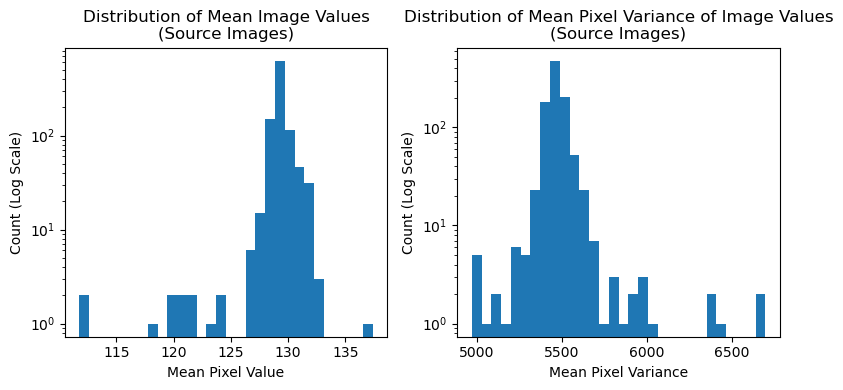

In [74]:
# Distribution of means
data = train_stats["source_img_mean"]

fig,ax = plt.subplots(1,2, figsize=(8,4))
ax[0].hist(data, bins=30, log=True)
ax[0].set(title="Distribution of Mean Image Values\n(Source Images)",
          xlabel="Mean Pixel Value",
          ylabel="Count (Log Scale)"
         )
ax[1].hist(train_stats["source_img_var"], bins=30, log=True)
ax[1].set(title="Distribution of Mean Pixel Variance of Image Values\n(Source Images)",
          xlabel="Mean Pixel Variance",
          ylabel="Count (Log Scale)"
         )

plt.tight_layout()
plt.show()

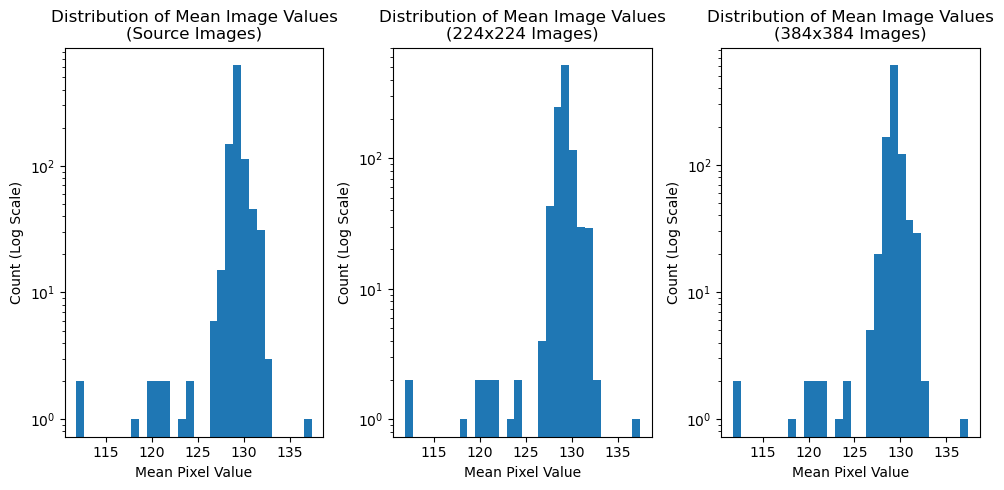

In [75]:
# Distribution of means
fig,axes = plt.subplots(1,3, figsize=(10,5))
ax = axes.flatten()

ax[0].hist(train_stats["source_img_mean"], bins=30, log=True)
ax[0].set(title="Distribution of Mean Image Values\n(Source Images)",
          xlabel="Mean Pixel Value",
          ylabel="Count (Log Scale)"
         )
ax[1].hist(train_stats["base224_img_mean"], bins=30, log=True)
ax[1].set(title="Distribution of Mean Image Values\n(224x224 Images)",
          xlabel="Mean Pixel Value",
          ylabel="Count (Log Scale)"
         )
ax[2].hist(train_stats["base384_img_mean"], bins=30, log=True)
ax[2].set(title="Distribution of Mean Image Values\n(384x384 Images)",
          xlabel="Mean Pixel Value",
          ylabel="Count (Log Scale)"
         )

plt.tight_layout()
plt.show()

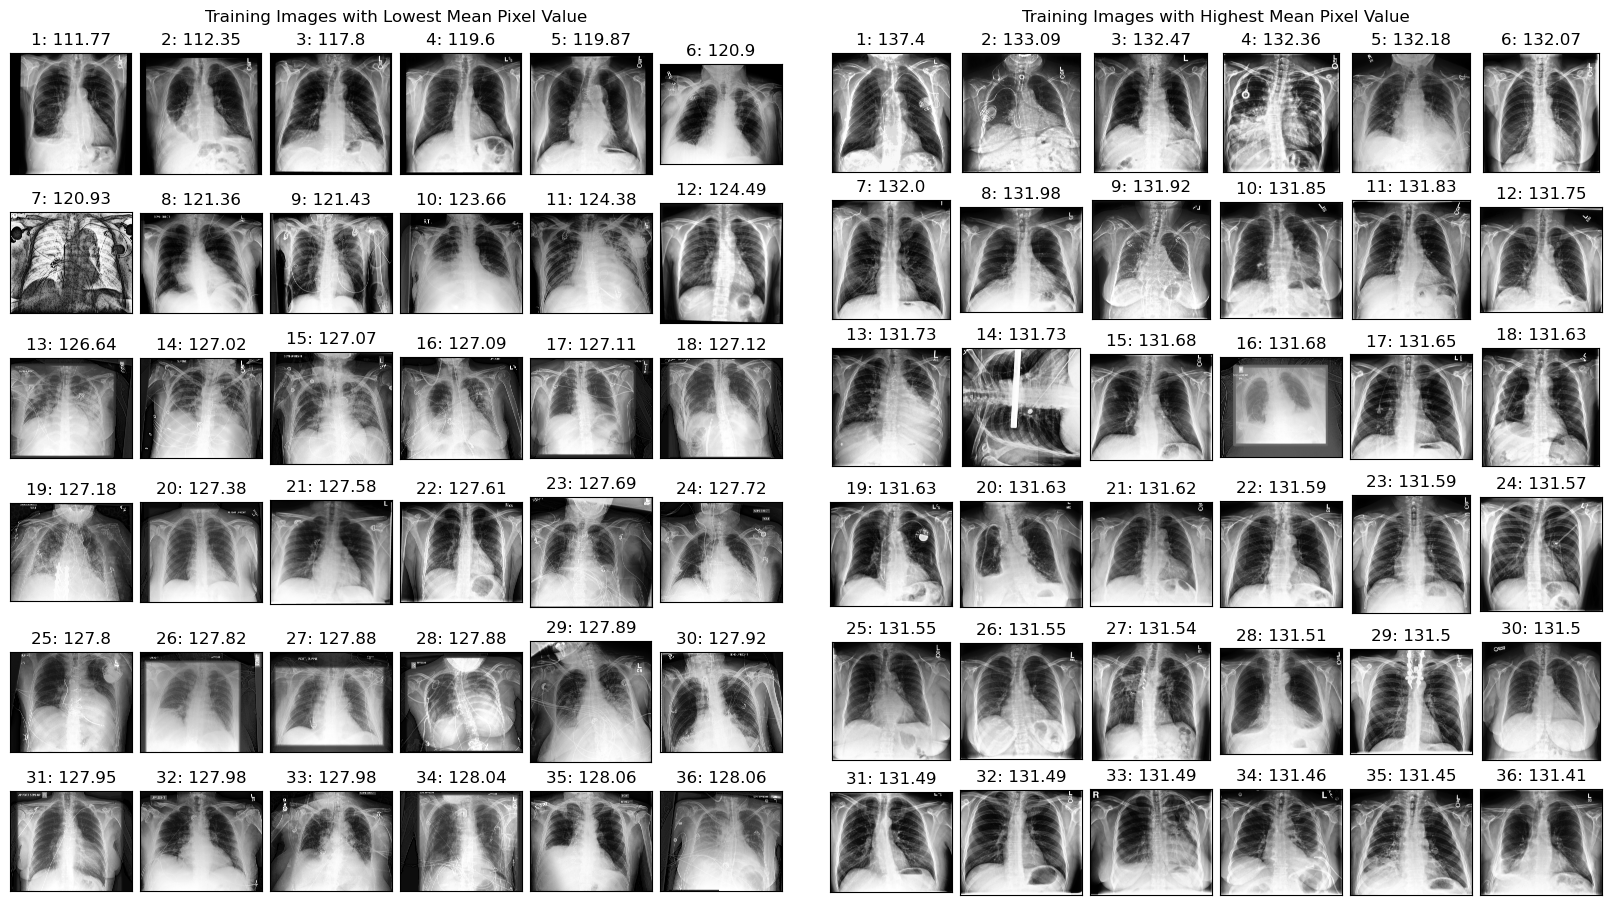

In [76]:
# Viewing the images with the lowest variances
var = "source_img_mean"
df = train_stats.sort_values(by=var, ascending=True)[source_cols]

# --- Prepare subfigures
fig = plt.figure(constrained_layout=True, figsize=(16,9))
subfigs = fig.subfigures(1,2, wspace=0.05)
subfigs[0].suptitle("Training Images with Lowest Mean Pixel Value")
subfigs[1].suptitle("Training Images with Highest Mean Pixel Value")

axes0 = subfigs[0].subplots(6,6)
axes1 = subfigs[1].subplots(6,6)

# --- Get data and display it
df0 = df.head(36)[source_cols]
for i,(ax,img_var,path) in enumerate(zip(axes0.flatten(), df0[var], df0["source_file_path"]), start=1):
    with Image.open(path) as img:
        ax.imshow(img, cmap="gray")
        ax.set(title=f"{i}: {round(img_var,2)}",xticks=[], yticks=[])
df1 = df.tail(36)[source_cols][::-1]
for i,(ax,img_var,path) in enumerate(zip(axes1.flatten(), df1[var], df1["source_file_path"]), start=1):
    with Image.open(path) as img:
        ax.imshow(img, cmap="gray")
        ax.set(title=f"{i}: {round(img_var,2)}",xticks=[], yticks=[])

# fig.savefig("images/img_viewMeans.jpg")

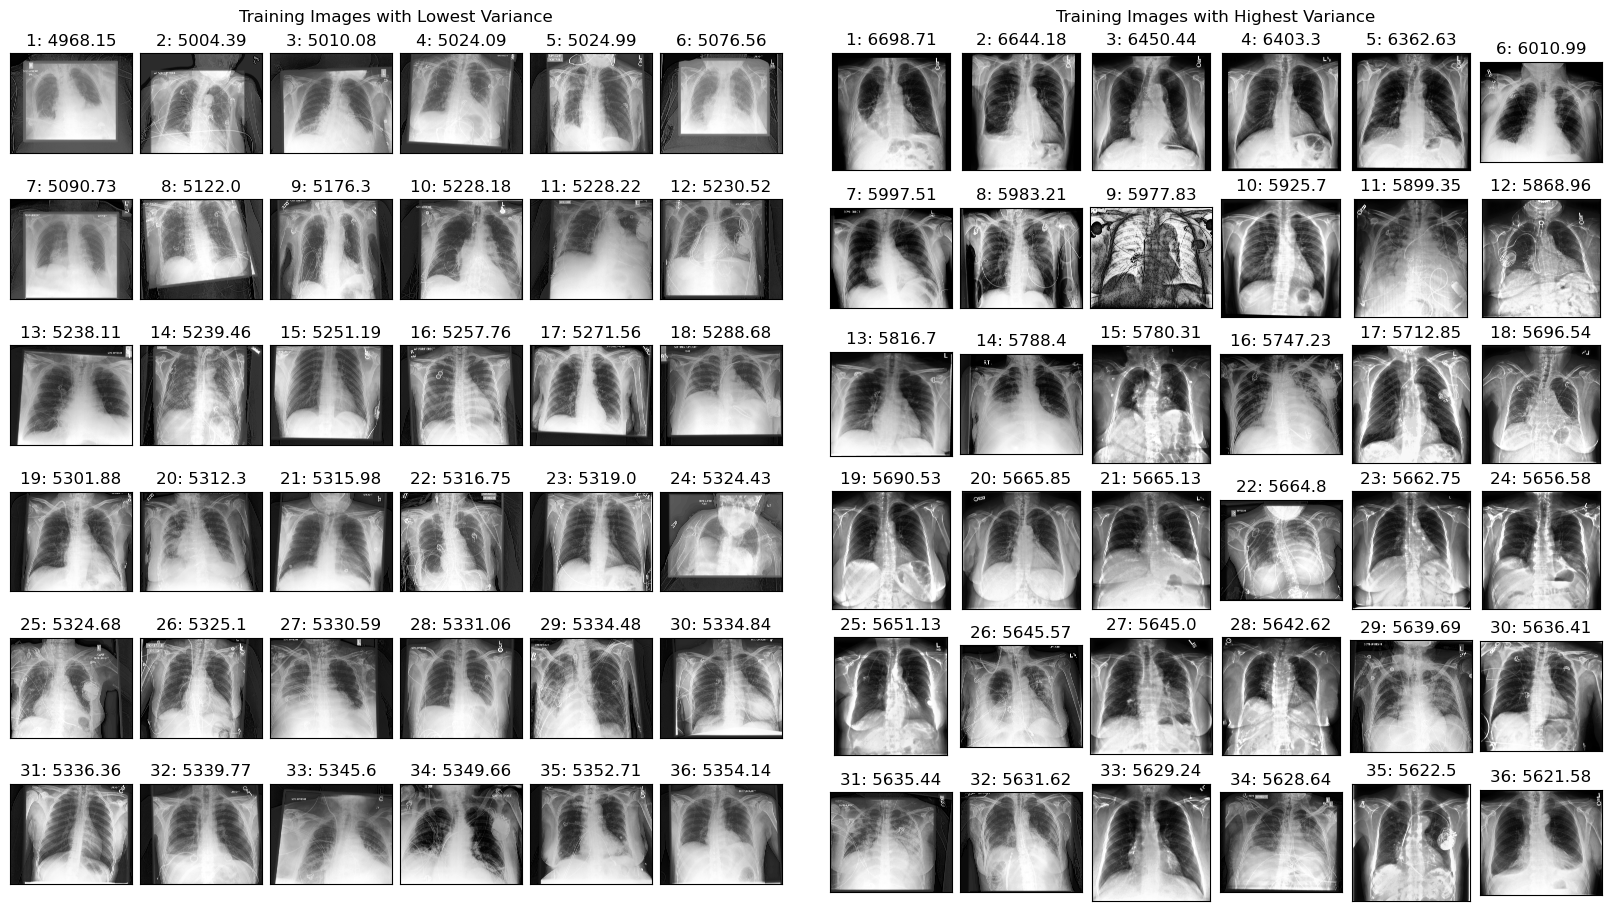

In [77]:
# Viewing the images with the lowest variances
var = "source_img_var"
df = train_stats.sort_values(by=var, ascending=True)[source_cols]

# --- Prepare subfigures
fig = plt.figure(constrained_layout=True, figsize=(16,9))
subfigs = fig.subfigures(1,2, wspace=0.05)
subfigs[0].suptitle("Training Images with Lowest Variance")
subfigs[1].suptitle("Training Images with Highest Variance")

axes0 = subfigs[0].subplots(6,6)
axes1 = subfigs[1].subplots(6,6)

# --- Get data and display it
df0 = df.head(36)[source_cols]
for i,(ax,img_var,path) in enumerate(zip(axes0.flatten(), df0[var], df0["source_file_path"]), start=1):
    with Image.open(path) as img:
        ax.imshow(img, cmap="gray")
        ax.set(title=f"{i}: {round(img_var,2)}",xticks=[], yticks=[])
df1 = df.tail(36)[source_cols][::-1]
for i,(ax,img_var,path) in enumerate(zip(axes1.flatten(), df1[var], df1["source_file_path"]), start=1):
    with Image.open(path) as img:
        ax.imshow(img, cmap="gray")
        ax.set(title=f"{i}: {round(img_var,2)}",xticks=[], yticks=[])

# fig.savefig("images/img_viewVariances.jpg")

f"{source_train_root}patient28397/study2/view1_frontal.jpg",
f"{source_train_root}patient23744/study31/view1_frontal.jpg",
f"{source_train_root}patient04613/study7/view1_frontal.jpg",
f"{source_train_root}patient31526/study3/view1_frontal.jpg",
f"{source_train_root}patient42638/study3/view1_frontal.jpg",
f"{source_train_root}patient17089/study1/view1_frontal.jpg",
f"{source_train_root}patient21729/study1/view1_frontal.jpg",
f"{source_train_root}patient15712/study1/view1_frontal.jpg",
f"{source_train_root}patient14828/study1/view1_frontal.jpg",
f"{source_train_root}patient33939/study1/view1_frontal.jpg",
f"{source_train_root}patient08928/study1/view1_frontal.jpg",
f"{source_train_root}patient10911/study1/view1_frontal.jpg",
f"{source_train_root}patient27078/study4/view1_frontal.jpg",


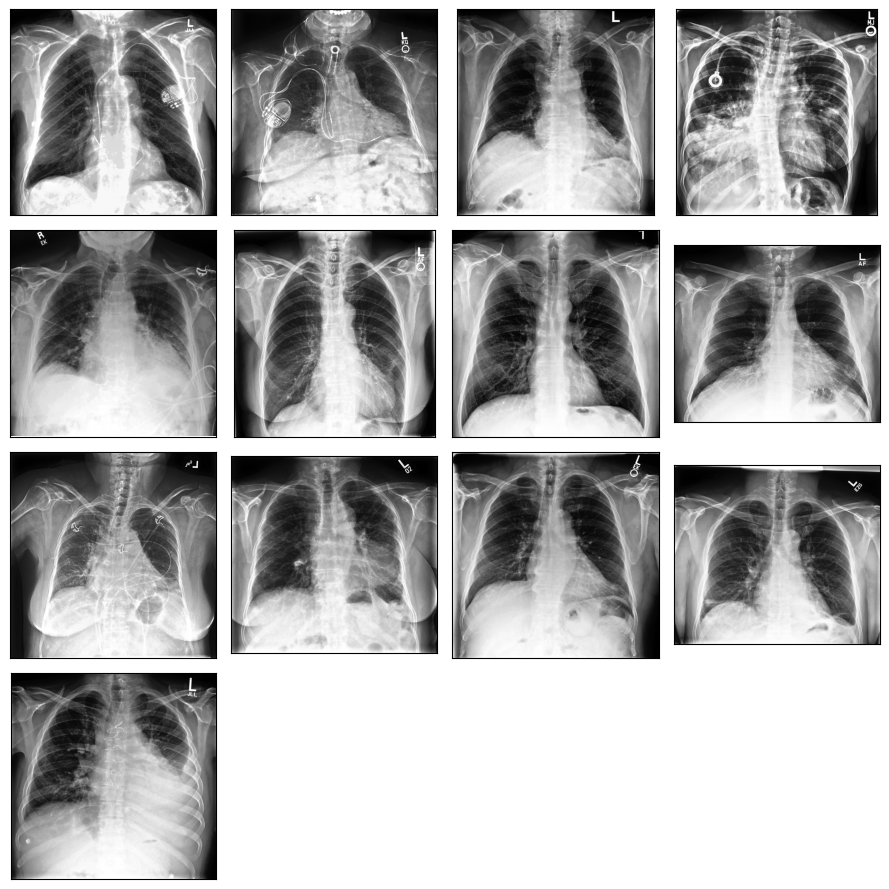

In [78]:
# Viewing the first 13 images in train_stats with the highest mean value
filter_out_paths = list(train_stats.sort_values(by="source_img_mean", ascending=False).head(13)["source_file_path"])

for path in list(train_stats.sort_values(by="source_img_mean", ascending=False).head(13)["floating_file_path"]):
    print("f\"{source_train_root}" + path + "\",")

#
fig,axes = plt.subplots(4,4, figsize=(9,9))

# --- Uncomment this to view only the first 13 images
for i,ax in enumerate(axes.flatten()):
    if i > 12: 
        ax.axis("off")
    else:
        with Image.open(filter_out_paths[i]) as img:
            ax.imshow(img, cmap="gray")
            ax.set(xticks=[], yticks=[])

# # --- Uncomment this to view all images
# for i,ax in enumerate(axes.flatten()):
#     with Image.open(filter_out_paths[i]) as img:
#         ax.imshow(img, cmap="gray")
#         ax.set(xticks=[], yticks=[])

plt.tight_layout()
# fig.savefig("images/error_images.jpg")

In [79]:
n = 27865
bins = 255
path_type = "source_file_path"

In [80]:
def get_psnr(img_arr, img_arr2, scale_max):
    """ Calculates the peak signal-to-noise ratio in dB between an edited image (img_arr2) and the original (img_arr)"""
    img_arr = img_arr.astype(np.float64)
    img_arr2 = img_arr2.astype(np.float64)
    mse = np.mean((img_arr - img_arr2)**2)
    if mse==0: 
        return np.inf
    else:
        return 20 * math.log10(scale_max) - 10 * math.log10(mse)

In [81]:
def unsharp_masking(img_arr, sigma, weight):
    """Enhance the image by increasing edge contrasts"""
    blurred = gaussian_filter(img_arr, sigma)
    return img_arr + (img_arr - blurred) * weight

In [82]:
# Testing sharpening and contrast increases

# --- Get image
with Image.open(train_df.loc[n, path_type]) as img:
    img_arr = np.array(img)
img_arr = scale_range(img_arr, scale_min, scale_max) 

# --- Histogram equalization
he_sigma = 5
img_arr_he = histogram_equalization(img_arr, scale_min, scale_max, he_sigma)    

# --- Sharpening with convolve filter + histogram equalization
center = 9
edge = -1
corner = -1

sharpen_kernel = np.array([[corner, edge, corner],
                           [edge,   center, edge],
                           [corner, edge, corner]])

conv = convolve(img_arr, sharpen_kernel)
conv = scale_range(conv, scale_min, scale_max)
conv_he = histogram_equalization(conv, scale_min, scale_max, he_sigma)
#
conv_psnr = get_psnr(img_arr, conv, scale_max)
conv_he_psnr = get_psnr(img_arr, conv_he, scale_max)
conv_ssim = structural_similarity(img_arr, conv, data_range=(scale_max-scale_min))
conv_he_ssim = structural_similarity(img_arr, conv_he, data_range=(scale_max-scale_min))

# --- Unsharp Masking + histogram equalization
usm_sigma = 10
weight = 1.2

usm = unsharp_masking(img_arr, usm_sigma, weight)
usm = scale_range(usm, scale_min, scale_max)
usm_he = histogram_equalization(usm, scale_min, scale_max, he_sigma)
#
usm_psnr = get_psnr(img_arr, usm, scale_max)
usm_he_psnr = get_psnr(img_arr, usm_he, scale_max)
usm_ssim = structural_similarity(img_arr, usm, data_range=(scale_max-scale_min))
usm_he_ssim = structural_similarity(img_arr, usm_he, data_range=(scale_max-scale_min))


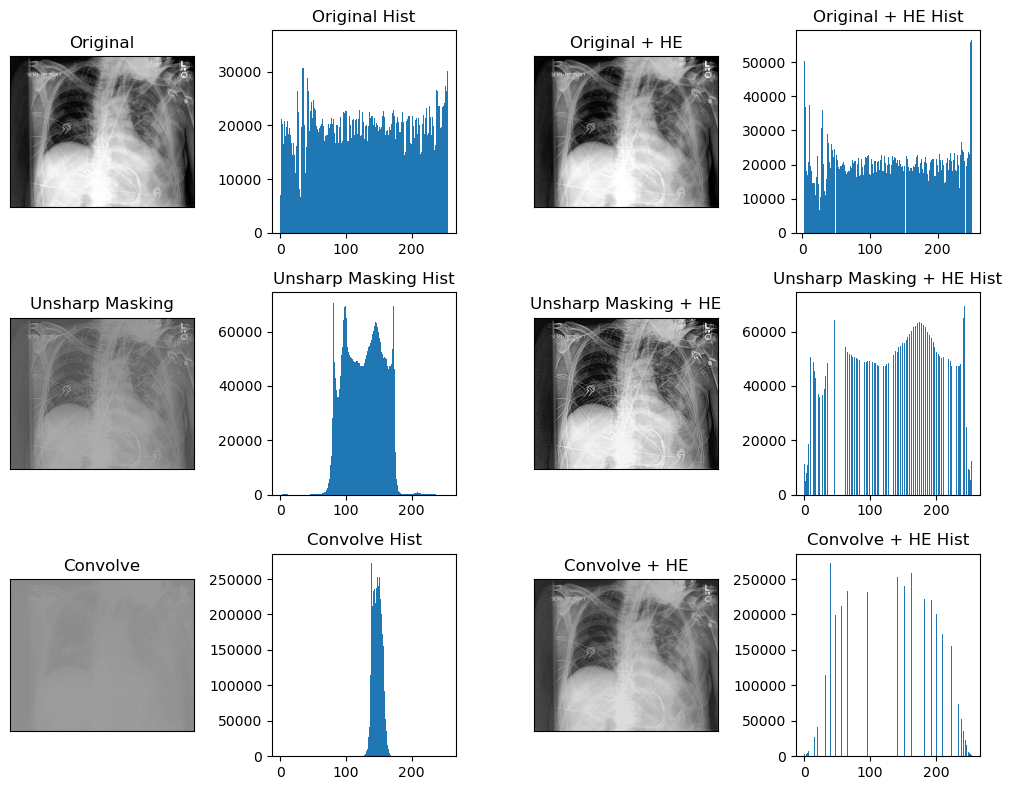

In [83]:
fig,axes = plt.subplots(3,4,figsize=(10,8))
ax = axes.flatten()

###
ax[0].imshow(img_arr, cmap="gray")
ax[0].set(title="Original", xticks=[], yticks=[])
#
ax[1].hist(img_arr.flatten(), bins=bins)
ax[1].set(title="Original Hist")
#
ax[2].imshow(img_arr_he, cmap="gray")
ax[2].set(title="Original + HE", xticks=[], yticks=[])
#
ax[3].hist(img_arr_he.flatten(), bins=bins)
ax[3].set(title="Original + HE Hist")
#####
ax[4].imshow(usm, cmap="gray")
ax[4].set(title="Unsharp Masking", xticks=[], yticks=[])
#
ax[5].hist(usm.flatten(), bins=bins)
ax[5].set(title="Unsharp Masking Hist")
#
ax[6].imshow(usm_he, cmap="gray")
ax[6].set(title="Unsharp Masking + HE", xticks=[], yticks=[])
#
ax[7].hist(usm_he.flatten(), bins=bins)
ax[7].set(title="Unsharp Masking + HE Hist")
#####
ax[8].imshow(conv, cmap="gray")
ax[8].set(title="Convolve", xticks=[], yticks=[])
#
ax[9].hist(conv.flatten(), bins=bins)
ax[9].set(title="Convolve Hist")
#
ax[10].imshow(conv_he, cmap="gray")
ax[10].set(title="Convolve + HE", xticks=[], yticks=[])
#
ax[11].hist(conv_he.flatten(), bins=bins)
ax[11].set(title="Convolve + HE Hist")

plt.tight_layout()
plt.show()


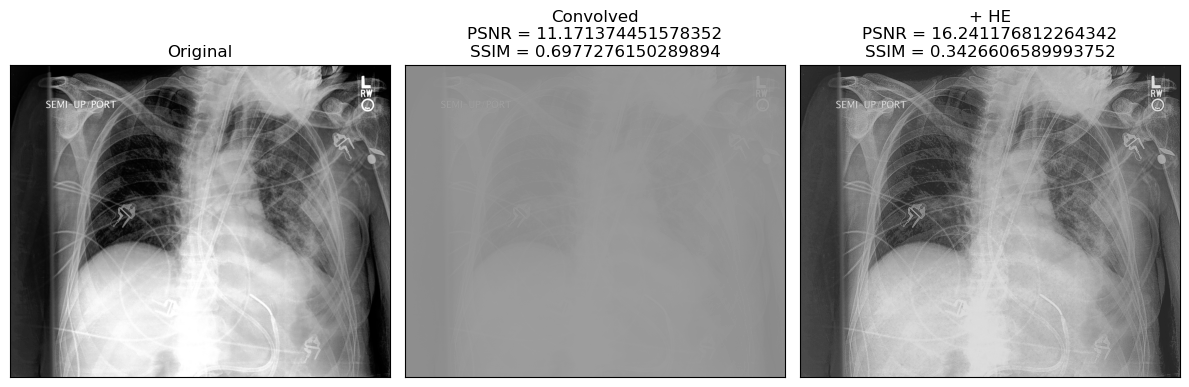

In [84]:
fig,ax = plt.subplots(1,3,figsize=(12,7))

ax[0].imshow(img_arr_he, cmap="gray")
ax[0].set(title="Original", xticks=[], yticks=[])

ax[1].imshow(conv, cmap="gray")
ax[1].set(title=f"Convolved\nPSNR = {conv_psnr}\nSSIM = {conv_ssim}", xticks=[], yticks=[])

ax[2].imshow(conv_he, cmap="gray")
ax[2].set(title=f"+ HE\nPSNR = {conv_he_psnr}\nSSIM = {conv_he_ssim}", xticks=[], yticks=[])

plt.tight_layout()
plt.show()

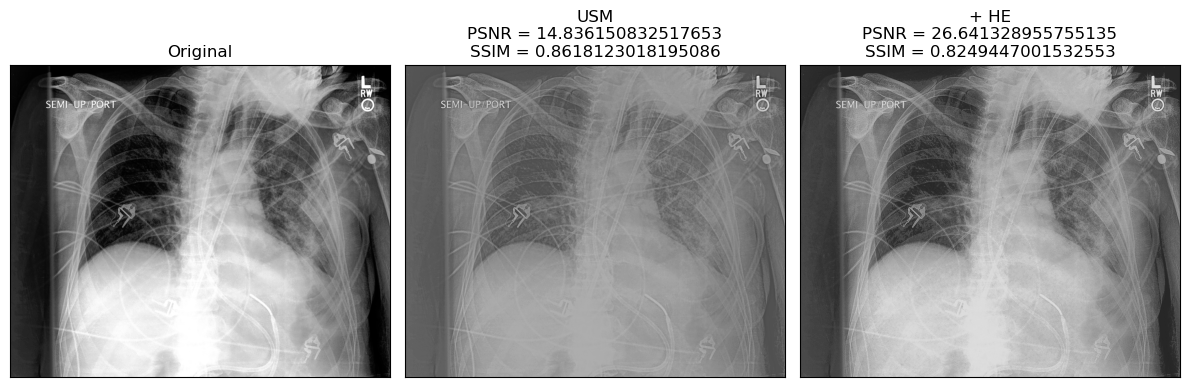

In [85]:
fig,ax = plt.subplots(1,3,figsize=(12,7))

ax[0].imshow(img_arr_he, cmap="gray")
ax[0].set(title="Original", xticks=[], yticks=[])

ax[1].imshow(usm, cmap="gray")
ax[1].set(title=f"USM\nPSNR = {usm_psnr}\nSSIM = {usm_ssim}", xticks=[], yticks=[])

ax[2].imshow(conv_he, cmap="gray")
ax[2].set(title=f"+ HE\nPSNR = {usm_he_psnr}\nSSIM = {usm_he_ssim}", xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [86]:
def pipeline1(img_arr, kernel, he_sigma, scale_min, scale_max):
    """Scale the range, sharpen by convolving with a kernel, then equalize the histogram"""
    output = scale_range(img_arr, scale_min, scale_max)
    output = convolve(output, kernel)
    output = histogram_equalization(output, scale_min, scale_max, he_sigma)
    return output

def pipeline2(img_arr, weight, usm_sigma, he_sigma, scale_min, scale_max):
    """Scale the range, sharpen via unsharp masking, then equalize the histogram"""
    output = scale_range(img_arr, scale_min, scale_max)
    output = unsharp_masking(output, usm_sigma, weight)
    output = histogram_equalization(output, scale_min, scale_max, he_sigma)
    return output

In [87]:
test1 = pipeline1(img_arr, sharpen_kernel, he_sigma, scale_min, scale_max)
test2 = pipeline2(img_arr, weight, usm_sigma, he_sigma, scale_min, scale_max)

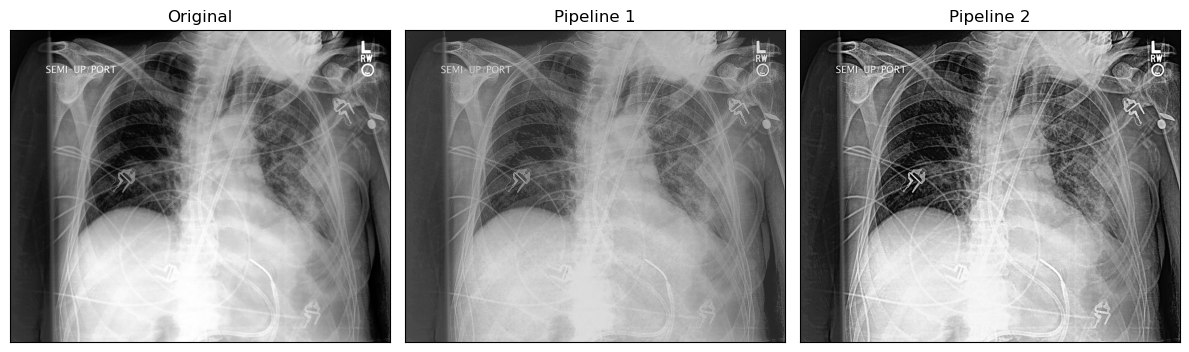

In [88]:
fig,ax = plt.subplots(1,3,figsize=(12,7))

ax[0].imshow(img_arr, cmap="gray")
ax[0].set(title="Original", xticks=[], yticks=[])

ax[1].imshow(test1, cmap="gray")
ax[1].set(title="Pipeline 1", xticks=[], yticks=[])

ax[2].imshow(test2, cmap="gray")
ax[2].set(title="Pipeline 2", xticks=[], yticks=[])

plt.tight_layout()
plt.show()